In [1]:

import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "loop_MTP_paper_evals"

In [2]:
RUN_IDS = {
    "ACC": [
        # "o4of3qst", # 3 loops
        "4syest5b", # 7 loops
        "sou7e1qa", # 9 loops
        "snksxen7", # 11 loops
        "udv2wpb0", # 13 loops
        "cznfs3qy", # 15 loops
    ],
    "BPB": [
        # "8djd4ntg", # 3 loops
        "2o1440xt", # 7 loops
        "606f3mwt", # 9 loops
        "zjokulqz", # 11 loops
        "rpr72lj4", # 13 loops
        "bopx80fl", # 15 loops

    ],
}
assert len(RUN_IDS["ACC"]) == len(RUN_IDS["BPB"]), "ACC and BPB run lists must align"

In [3]:
ACC_KEY = "eval_full/gsm8k::olmes"
BPB_KEY = "eval_full/olmo3:base_easy:math_bpb"

acc_dict = {}        # run_name -> list of acc values (percentage)
bpb_dict = {}        # run_name -> list of bpb values
acc_steps = {}       # run_name -> seen_steps_full (steps where ACC_KEY logged)
bpb_steps = {}       # run_name -> seen_steps     (steps where BPB_KEY logged)

api = wandb.Api()
# ACC and BPB may come from different runs; pair them by position in the lists.
for acc_id, bpb_id in zip(RUN_IDS["ACC"], RUN_IDS["BPB"]):
    acc_run = api.run(f"{ENTITY}/{PROJECT}/{acc_id}")
    bpb_run = api.run(f"{ENTITY}/{PROJECT}/{bpb_id}")
    run_name = acc_run.name  # use the ACC run's name as the pairing key/label

    # scan_history streams every logged row (not the ~500-row sampled history),
    # so sparse eval keys are preserved. Keep only rows where the key is present.
    acc_rows = [r for r in acc_run.scan_history(keys=["_step", ACC_KEY])
                if r.get(ACC_KEY) is not None]
    bpb_rows = [r for r in bpb_run.scan_history(keys=["_step", BPB_KEY])
                if r.get(BPB_KEY) is not None]

    # accuracy -> percentage
    acc_dict[run_name]  = [r[ACC_KEY] * 100 for r in acc_rows]
    acc_steps[run_name] = [r["_step"] for r in acc_rows]   # seen_steps_full
    bpb_dict[run_name]  = [r[BPB_KEY] for r in bpb_rows]
    bpb_steps[run_name] = [r["_step"] for r in bpb_rows]    # seen_steps

    print(f"{run_name}: {len(acc_dict[run_name])} acc pts @ steps {acc_steps[run_name]}")
    print(f"{' ' * len(run_name)}  {len(bpb_dict[run_name])} bpb pts @ steps {bpb_steps[run_name]}")

# ---------------------------------------------------------------------------
# Manual data placeholder.
# Add points that aren't in W&B (e.g. a run with missing logging, or an
# external baseline). Key = label shown in the plot (use "L=.." or "BASELINE"
# so it matches the existing label logic). acc is in PERCENT, bpb is raw.
# ---------------------------------------------------------------------------
MANUAL_DATA = {
    # "L=7":  {"bpb": 0.000, "acc": 16.679},
}

_DUMMY_STEP = 27969  # so manual points merge cleanly with W&B final-eval steps
for label, d in MANUAL_DATA.items():
    acc_dict[label]  = [d["acc"]]
    bpb_dict[label]  = [d["bpb"]]
    acc_steps[label] = [_DUMMY_STEP]
    bpb_steps[label] = [_DUMMY_STEP]
    print(f"[manual] {label}: bpb={d['bpb']}, acc={d['acc']}%")

wandb: Currently logged in as: behzadshomali to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


TunedAlign_WD0.132_AlignedHidden0.05_woAlignemnt_12Block_HigherAlign_ScalerBias_woSigmoid_UniversalGate_DiffAlign_CoolLNS_woMTP_[0.55, -3.0, -3.5, -4.0, -4.5, -5.0, -5.5]_AlignedHidden0.05_NormEmbdsFalse_alfFalse_woShift_WS_k=12_L=7_[[0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11]]_2026-06-06__14-00-43_b9a1710184be7088 (merged-into-4bvxutp0): 1 acc pts @ steps [0]
                                                                                                                                                                                                                                                                                                                                                           1 bpb pts @ steps [0]
TunedAlign_WD0.132_AlignedHidden0.15_woAlignemnt_12Block_HigherAlign_ScalerBias_woSigmoid_UniversalGate_DiffAlign_CoolLNS_woMTP_[0.55, -3.0, -3.5, -4.0, -4.5, -5.0, -5.5, -6.0, -6.5]_AlignedHidden0.15_NormEmbdsFalse_alfFalse_woShift_WS_k=12_L=9_[[0, -1, -2, -3, 

In [4]:
def modify_label(lab):
    if "BASELINE" in lab.upper():
        return "non-looped"
    lab = lab.replace("L=", "LoopMTP (k=")
    lab = lab.replace("3", "3)")
    lab = lab.replace("5", "5)")
    lab = lab.replace("7", "7)")
    lab = lab.replace("9", "9)")

    return lab

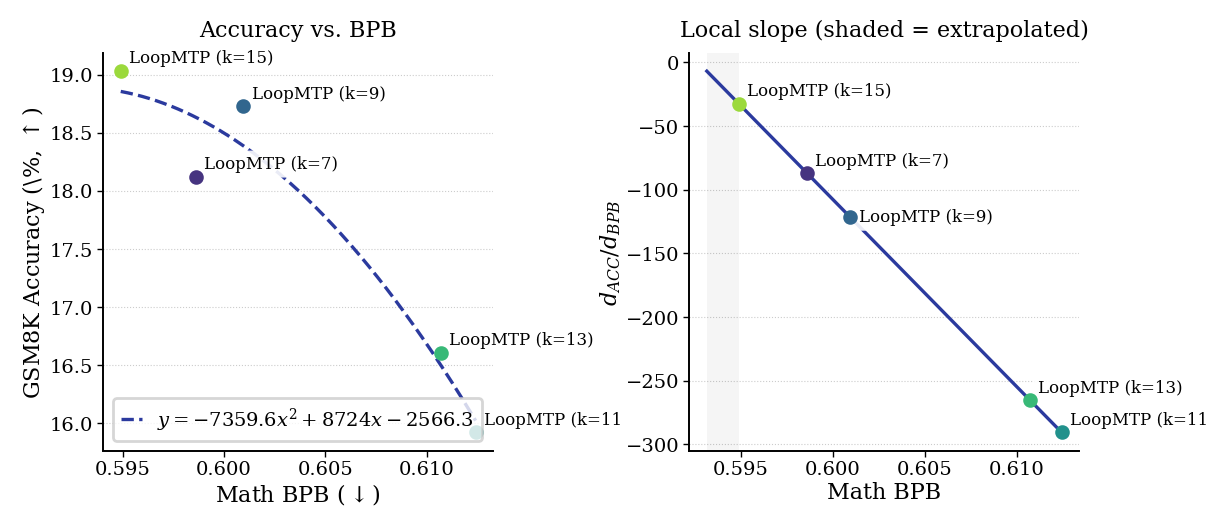

deg-2 fit: y = -7359.5797 x^2 + 8723.7121 x + -2566.2817
slope(x)  = -14719.1593 x + 8723.7121


In [5]:
import re
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

# ---------------------------------------------------------------------------
# Collect one final-eval (bpb, acc) point per run.
# ---------------------------------------------------------------------------
all_bpb, all_acc, point_labels = [], [], []

for run_name in acc_dict:
    acc_df = pd.DataFrame({"_step": acc_steps[run_name], "acc": acc_dict[run_name]})
    bpb_df = pd.DataFrame({"_step": bpb_steps[run_name], "bpb": bpb_dict[run_name]})
    if acc_df.empty or bpb_df.empty:
        print(f"skipping {run_name}: missing acc or bpb")
        continue

    merged = pd.merge_asof(
        acc_df.sort_values("_step"),
        bpb_df.sort_values("_step"),
        on="_step",
        direction="nearest",
    )

    if "BASELINE" in run_name.upper():
        label = "BASELINE"
    else:
        m = re.search(r"L=\d+", run_name)
        label = m.group(0) if m else run_name

    all_bpb.extend(merged["bpb"].tolist())
    all_acc.extend(merged["acc"].tolist())
    point_labels.extend([label] * len(merged))

all_bpb = np.array(all_bpb)
all_acc = np.array(all_acc)

# Degree-2 polynomial fit + its derivative (slope)
coeffs = np.polyfit(all_bpb, all_acc, 2)         # [a, b, c] for a*x^2 + b*x + c
poly   = np.poly1d(coeffs)
dpoly  = np.polyder(poly)                        # slope(x) = 2a*x + b
a, b, c = coeffs

colors = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.85, len(all_bpb))]


EXCLUDE_NON_LOOPED = True

# x-ranges: tight for the fit, slightly extrapolated for the slope panel
span = all_bpb.max() - all_bpb.min()
pad  = 0.05 * span if span > 0 else 0.001
extr = 0.1 * span if span > 0 else 0.01        # extrapolation margin
xs       = np.linspace(all_bpb.min(), all_bpb.max(), 200)


xs_extra = np.linspace(all_bpb.min() - extr, all_bpb.max(), 200)
all_bpb_temp = all_bpb
if EXCLUDE_NON_LOOPED:
    all_bpb_temp = [bp for bp, lab in zip(all_bpb, point_labels) if "BASELINE" not in lab.upper()]
    all_bpb_temp = np.array(all_bpb_temp)
    xs_extra = np.linspace(min(all_bpb_temp) - extr, max(all_bpb_temp), 200)

fig, (ax_right, ax_left) = plt.subplots(1, 2, figsize=(6., 2.5))

# ── Panel A: scatter + deg-2 fit ─────────────────────────────────────────────
for x, y, lab, col in zip(all_bpb, all_acc, point_labels, colors):
    x_offset = 0
    y_offset = 0
    if "BASELINE" in lab.upper():
        x_offset = -0.007
        y_offset = 0.5
    lab = modify_label(lab)
    ax_right.scatter(x, y, color=col, s=18, zorder=5)#, label=lab)
    ax_right.annotate(lab, (x + x_offset, y + y_offset), textcoords="offset points", xytext=(3, 3), fontsize=6, bbox=dict(boxstyle="round", fc="white", alpha=0.9, lw=0))

ax_right.plot(xs, poly(xs), "--", color="#2b3a9e", linewidth=1.2, zorder=2,
         label=f"$y = {a:.1f}x^2 {b:+.0f}x {c:+.1f}$")
ax_right.set_xlim(all_bpb.min() - pad, all_bpb.max() + pad)
ax_right.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax_right.set_xlabel("Math BPB ($\\downarrow$)", labelpad=1)
ax_right.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=1)
ax_right.set_title("Accuracy vs. BPB")
# ax_right.legend(frameon=True, framealpha=0.8, edgecolor="#cccccc", handlelength=1.6,loc="upper center",
    # bbox_to_anchor=(0.5, 1.25))

ax_right.legend(
    # loc="lower left",
    # bbox_to_anchor=(-0.01, -0.01),
    columnspacing=1.0,
    handlelength=1.1,
    frameon=True,
    framealpha=0.8,
    edgecolor="#cccccc",
)

# ── Panel B: slope dACC/dBPB across BPB (with extrapolation) ──────────────────
# Shade the extrapolated region beyond the observed data.
ax_left.axvspan(xs_extra.min(), all_bpb_temp.min(), color="#000000", alpha=0.04, lw=0)
ax_left.axvspan(all_bpb_temp.max(), xs_extra.max(), color="#000000", alpha=0.04, lw=0)
# ax_left.axhline(0, color="#888888", linewidth=0.6, linestyle="-", zorder=1)

ax_left.plot(xs_extra, dpoly(xs_extra), "-", color="#2b3a9e", linewidth=1.2, zorder=2,
         )

for x, lab, col in zip(all_bpb, point_labels, colors):
    if "BASELINE" in lab.upper() and EXCLUDE_NON_LOOPED:
        continue
    x_offset = 0
    y_offset = 0
    lab = modify_label(lab)
    if "k=9" in lab:
        y_offset = -10
    elif "k=3" in lab:
        x_offset = -0.005
    ax_left.scatter(x, dpoly(x), color=col, s=18, zorder=5)
    ax_left.annotate(lab, (x + x_offset, dpoly(x) + y_offset), textcoords="offset points", xytext=(3, 3), fontsize=6, bbox=dict(boxstyle="round", fc="white", alpha=0.9, lw=0))

ax_left.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax_left.set_xlabel("Math BPB", labelpad=1)
ax_left.set_ylabel("$d_{ACC}/d_{BPB}$", labelpad=1)
ax_left.set_title("Local slope (shaded = extrapolated)")
# ax_left.legend(frameon=True, framealpha=0.8, edgecolor="#cccccc", handlelength=1.6)

for ax in (ax_right, ax_left):
    ax.tick_params(length=2, pad=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)

# fig.tight_layout(pad=0.3, w_pad=0)
fig.tight_layout(pad=0.3, w_pad=-1, h_pad=2)
Path("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots").mkdir(exist_ok=True)
fig.savefig("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots/bpb_vs_acc_sensitivity.pdf", bbox_inches="tight")
plt.show()

print(f"deg-2 fit: y = {a:.4f} x^2 + {b:.4f} x + {c:.4f}")
print(f"slope(x)  = {2*a:.4f} x + {b:.4f}")


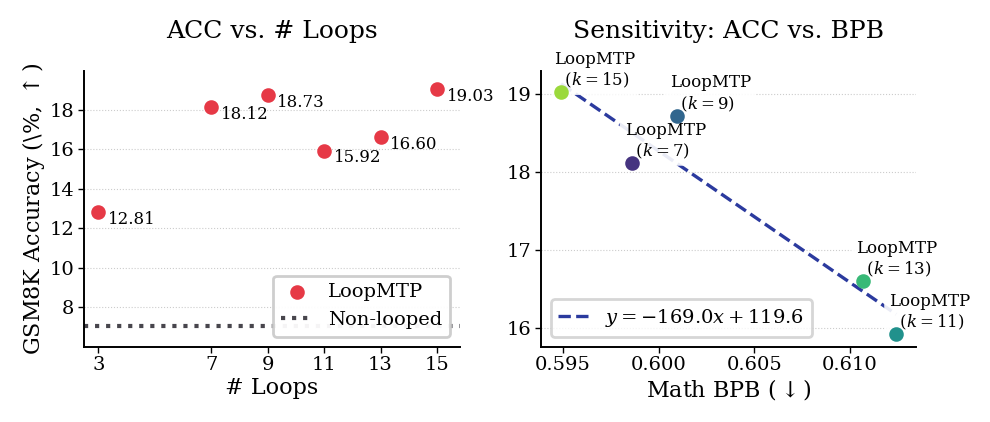

linear fit: y = -168.9603 x + 119.6497


In [6]:
EXCLUDE_NON_LOOP = False

import re
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ---------------------------------------------------------------------------
# Sensitivity view: small BPB differences -> pronounced ACC changes.
# Each run contributes ~one final-eval point; pool them, scatter (colored per
# run), fit a line, and report the (constant) slope dACC/dBPB.
# ---------------------------------------------------------------------------
all_bpb, all_acc, point_labels = [], [], []

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(5, 2.15))

for run_name in acc_dict:
    acc_df = pd.DataFrame({"_step": acc_steps[run_name], "acc": acc_dict[run_name]})
    bpb_df = pd.DataFrame({"_step": bpb_steps[run_name], "bpb": bpb_dict[run_name]})
    if acc_df.empty or bpb_df.empty:
        print(f"skipping {run_name}: missing acc or bpb")
        continue

    merged = pd.merge_asof(
        acc_df.sort_values("_step"),
        bpb_df.sort_values("_step"),
        on="_step",
        direction="nearest",
    )

    if "BASELINE" in run_name.upper():
        label = "BASELINE"
    else:
        m = re.search(r"L=\d+", run_name)
        label = m.group(0) if m else run_name

    all_bpb.extend(merged["bpb"].tolist())
    all_acc.extend(merged["acc"].tolist())
    point_labels.extend([label] * len(merged))

all_bpb = np.array(all_bpb)
all_acc = np.array(all_acc)

# Distinct colors per point (viridis spread, like the other panels)
colors = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.85, len(all_bpb))]

if EXCLUDE_NON_LOOP:
    filtered = [(x, y, lab, c) for x, y, lab, c in zip(all_bpb, all_acc, point_labels, colors)
                if "BASELINE" not in lab.upper()]
    all_bpb, all_acc, point_labels, colors = zip(*filtered)
    all_bpb = np.array(all_bpb)
    all_acc = np.array(all_acc)

for x, y, lab, c in zip(all_bpb, all_acc, point_labels, colors):
    lab = modify_label(lab)
    lab = lab.replace("LoopMTP", "")
    lab = lab.replace("(", "")
    lab = lab.replace(")", "")
    lab = "$" + lab + "$"
    lab = "LoopMTP\n" + "  (" + lab + ")"
    ax_right.scatter(x, y, color=c, s=18, zorder=5,) #label=lab)
    # set background color to blue

    x_pad = -0.0008
    y_pad = -0.02
    # if "11" in lab or "13" in lab:
    #     x_pad = -0.001
    ax_right.annotate(f"{lab}", (x+x_pad, y+y_pad), textcoords="offset points", xytext=(3, 3), fontsize=6, 
                bbox=dict(boxstyle="round", fc="white", alpha=0.9, lw=0))

# Linear fit (deg-1): slope is constant -> interpretable sensitivity
slope, intercept = np.polyfit(all_bpb, all_acc, 1)
poly = np.poly1d([slope, intercept])
eqn = f"$y = {slope:.1f}x {intercept:+.1f}$"
xs = np.linspace(all_bpb.min(), all_bpb.max(), 200)
ax_right.plot(xs, poly(xs), "--", color="#2b3a9e", linewidth=1.2, zorder=2, label=eqn)

# Tight x-limits so the (small) BPB spread fills the axis
span = all_bpb.max() - all_bpb.min()
pad = 0.06 * span if span > 0 else 0.001
ax_right.set_xlim(all_bpb.min() - pad, all_bpb.max() + pad)
ax_right.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

ax_right.set_xlabel("Math BPB ($\\downarrow$)", labelpad=1)
# ax_right.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=1)
ax_right.set_ylabel("", labelpad=1)
ax_right.tick_params(length=2, pad=1.5)
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)
ax_right.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax_right.set_axisbelow(True)
ax_right.legend(frameon=True, framealpha=0.8, edgecolor="#cccccc", handlelength=1.6, loc="lower left")
ax_right.set_title("Sensitivity: ACC vs. BPB", fontsize=9, pad=12)




# ── Subplot (left): GSM8K accuracy vs. # loops ──────────────────────────────────
loops_data   = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

coeffs = np.polyfit(loops_data, mtp_acc_data, 2)  # slope, intercept
poly   = np.poly1d(coeffs)

loops_extrap   = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

ax_left.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
for l, a in zip(loops_data, mtp_acc_data):
    ax_left.annotate(f"{a:.2f}", (l + 0.05, a - 1), textcoords="offset points", xytext=(3, 3), fontsize=6)

non_looped_baseline = 7.05
ax_left.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.5, label="Non-looped")

# ax_left.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
#          label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax_left.set_xlabel("# Loops", labelpad=1)
ax_left.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=1)
# ax_left.set_ylabel("", labelpad=1)
# ax_left.set_xticks(loops_extrap[::2])
ax_left.set_xticks(loops_data)
ax_left.tick_params(length=2, pad=1.5)
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax_left.set_axisbelow(True)
# ax_left.set_title("(a) Accuracy extrapolation", pad=3)
ax_left.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

ax_left.set_title("ACC vs. # Loops", fontsize=9, pad=12)
ax_left.set_xlim(2.5, 15.8)
ax_left.set_ylim(6.001, 19.95)
# ax_left.set_title("", fontsize=9, pad=4)

fig.tight_layout()
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation_wo_ppl.pdf", bbox_inches="tight")




fig.tight_layout(w_pad=0.5)
Path("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots").mkdir(exist_ok=True)
fig.savefig("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots/BPB_vs_ACC_sensitivity_and_ACC.pdf", bbox_inches="tight")
plt.show()

print(f"linear fit: y = {slope:.4f} x + {intercept:.4f}")
